<a href="https://colab.research.google.com/github/sthepaut/SAFRAN_ENSAI_2025/blob/ENSAI_students/performancemodel_ENSAI/notebook/genetic_algorithm_simple_simulation_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# !git clone https://github.com/Anonymous-GT11/SAFRAN_ENSAI_2025
!git clone -b ENSAI_students https://github.com/Anonymous-GT11/SAFRAN_ENSAI_2025


fatal: destination path 'SAFRAN_ENSAI_2025' already exists and is not an empty directory.


In [8]:
# Verify that we have sucessfully clone the repo and go the place where the repo is stored
%cd /content/SAFRAN_ENSAI_2025
!ls


/content/SAFRAN_ENSAI_2025
Cie_0_Engine0.csv	performancemodel_ENSAI.zip
performancemodel_ENSAI	README.md


In [9]:
# install the package performance_model
%cd /content/SAFRAN_ENSAI_2025/performancemodel_ENSAI/
!pip install .

/content/SAFRAN_ENSAI_2025/performancemodel_ENSAI
Processing /content/SAFRAN_ENSAI_2025/performancemodel_ENSAI
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for performancemodel: filename=performancemodel-0.0.1-py3-none-any.whl size=31132 sha256=10d90888277d5a5c5806ab00b8abe4d11c428bf5d0bb224ee04c3745ece6e1ea
  Stored in directory: /tmp/pip-ephem-wheel-cache-q9gfpcpv/wheels/b4/6e/66/25433221b4a4d2ead6faf834b0fa81054260e4a8996e629ab9
Successfully built performancemodel
  Attempting uninstall: performancemodel
    Found existing installation: performancemodel 0.0.1
    Uninstalling performancemodel-0.0.1:
      Successfully uninstalled performancemodel-0.0.1


In [10]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import time
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

from performancemodel.base_system import h_SCSF
from performancemodel.scenarios import simulate_degradation_trajectory, generate_multiple_trajectories
from performancemodel.plot import plot_trajectory



In [ ]:
import sys
import os
sys.path.append('/content/SAFRAN_ENSAI_2025/performancemodel_ENSAI/notebook')
from GA import GeneticAlgorithm
from GA_plots import plot_convergence_seaborn,plot_diversity_and_distribution,plot_ga_seaborn


#Estimate one measurement




In [ ]:
# Example: Estimate one measurement
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=2, seed=0)
true_traj =np.asarray(true_traj, dtype=float)[:,:2]
sensors = ['P3', 'T5']

# Get measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[0]  # First measurement

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")

import time
start_time = time.time()
# Create and run GA
ga = GeneticAlgorithm(

    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    pop_size=100,
    n_generations=5,
    target_fitness=10.0,
    stagnation_generations=20,
    min_improvement=0.001
)

best_solution, fitness_history = ga.evolve()
print("end_time")
print ( time.time() - start_time )

print(f"\nEstimated health: [{best_solution[0].item():.4f}, {best_solution[1].item():.4f}]")
print(f"Error: {np.abs(np.array(true_traj[0]) - best_solution.cpu().numpy())}")


True health: [1.00882026 1.00200079]
Target measurements: [1.79516603e+06 1.43208210e+03]


/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


Gen 0: Best Fit = 6.45, Avg Fit = 3.09, Pop SD = 0.0199, Genes (η_c, η_t) = [1.0105, 1.0022]
end_time
173.9340672492981

Estimated health: [1.0087, 1.0020]
Error: [8.28168522e-05 3.47125772e-05]


In [ ]:
true_traj

In [ ]:
import math

error_0 = abs(true_traj[0][0] - best_solution[0].item())  # eta_comp error
error_1 = abs(true_traj[0][1] - best_solution[1].item())  # eta_turb error

print("Error on eta_comp:", error_0)
print("Error on eta_turb:", error_1)


Error on eta_comp: 8.28168522137851e-05
Error on eta_turb: 3.471257724352306e-05


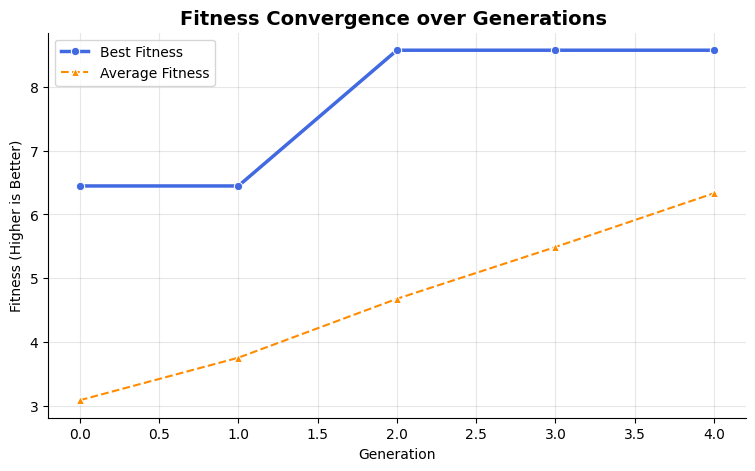

In [ ]:
plot_convergence_seaborn(ga)

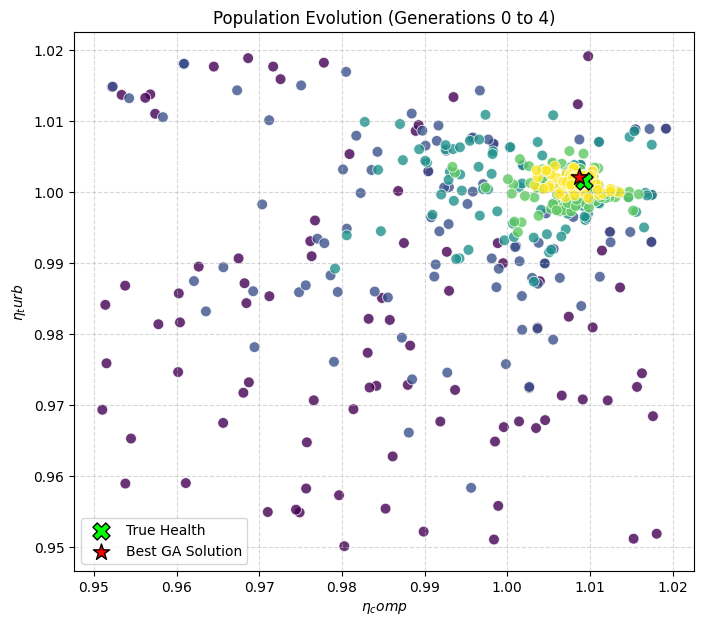

In [ ]:
plot_ga_seaborn(ga, best_solution, true_health=[1.0093, 1.0015])

In [ ]:
import time
import numpy as np

# ----------------------------------------------------------
# STEP 1 - Simulate True Health & Target Measurements
# ----------------------------------------------------------
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=100, seed=0)
# true_traj =np.asarray(true_traj, dtype=float)[:,:2]

sensors = ['P3', 'T5', 'W3R']

# Get simulated sensor measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[10]  # 55th sample

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")


# ----------------------------------------------------------
# STEP 2 — Create and Run the Genetic Algorithm
# ----------------------------------------------------------
start_time = time.time()

ga = GeneticAlgorithm(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    # REMOVED: n_genes=3 (The class figures this out from 'bounds' automatically)
    pop_size=100,
    n_generations=20,
    bounds=[(0.95, 1.02), (0.95, 1.02), (0.95, 1.02)], # 3 tuples = 3 genes
    mutation_rate=0.1,
    crossover_rate=0.9,
    tournament_size=3,
    n_elite=10,
    mutation_std_ratio=0.05
)

best_solution, fitness_history = ga.evolve(verbose_interval=5)

print("\n--- End of Evolution ---")
print(f"Execution time: {time.time() - start_time:.2f} s")

/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


True health: [1.0088202617298383, 1.002000786041836, 1.0048936899205287]
Target measurements: [1.79246835e+06 1.44332123e+03 3.00000000e+00]


TypeError: GeneticAlgorithm.__init__() got an unexpected keyword argument 'crossover_rate'